# Classification de commentaires YouTube

## Objectif du projet

L'objectif est de prédire la variable `CLASS` à partir des informations disponibles sur des commentaires YouTube.

La variable `CLASS` est binaire : on cherche donc à résoudre un problème de **classification**.

La démarche retenue dans cette version est volontairement progressive :

1. charger et comprendre les données ;
2. nettoyer les commentaires ;
3. créer quelques variables simples ;
4. représenter le texte avec **TF-IDF** ;
5. construire un premier modèle de classification ;
6. tester quelques valeurs d'hyperparamètres avec une validation croisée ;
7. évaluer le modèle sur un jeu de validation ;
8. réentraîner le modèle sur toutes les données d'entraînement ;
9. produire les prédictions du fichier `test_yt.csv`.

## 1. Importation des données

In [2]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

In [3]:
# Lecture des données
train = pd.read_csv("train_yt.csv")
test = pd.read_csv("test_yt.csv")

# On enlève les espaces inutiles dans les noms de colonnes.
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

print("Dimensions du train :", train.shape)
print("Dimensions du test  :", test.shape)

print("\nColonnes du train :")
print(train.columns.tolist())

train.head()

Dimensions du train : (1369, 7)
Dimensions du test  : (587, 6)

Colonnes du train :
['Unnamed: 0', 'COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'VIDEO_NAME', 'CLASS']


,Unnamed: 0,COMMENT_ID,AUTHOR,DATE,CONTENT,VIDEO_NAME,CLASS
0,1574,LneaDw26bFsFwQBcbaeKWWcSsBB7EA1zRf2nBgT9NyY,Ashim Limbu,NaN,HI IM 14 YEAR RAPPER SUPPORT ME GUY AND CHECK...,Eminem - Love The Way You Lie ft. Rihanna,1
1,859,z13zvnepkwvgirzi104cdf1pyyyecthieew,Ali Altınışık,2015-05-18T10:56:12.254000,Wow dance show﻿,"LMFAO - Party Rock Anthem ft. Lauren Bennett, ...",0
2,651,z12kh3rhbs3duzfea23hzf1qhlyuextzx04,Bobby Carlos,2014-11-06T16:30:30,"Lets be honest, you wouldn't last 1 day on you...",Katy Perry - Roar,0
3,1018,z12cvbyjjmuwvxivx223tpujulrwwdt5j04,ampai gmuer,2015-01-27T13:23:56.061000,Check out this playlist on YouTube:👿👳👳👳👳👳﻿,"LMFAO - Party Rock Anthem ft. Lauren Bennett, ...",1
4,1288,z13xx5w52svttd3lt23kijvwqtvph5m3l,sparkle princess,2015-05-26T07:39:34.920000,"do you guys know, there&#39;s a part two of th...",Eminem - Love The Way You Lie ft. Rihanna,0


## 2. Vérification rapide des données

On vérifie:

- les types de variables ;
- les valeurs manquantes ;
- la répartition de la variable cible ;
- les premières lignes du tableau.

Informations sur les données :
<class 'pandas.DataFrame'>
RangeIndex: 1369 entries, 0 to 1368
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  1369 non-null   int64
 1   COMMENT_ID  1369 non-null   str  
 2   AUTHOR      1369 non-null   str  
 3   DATE        1202 non-null   str  
 4   CONTENT     1369 non-null   str  
 5   VIDEO_NAME  1369 non-null   str  
 6   CLASS       1369 non-null   int64
dtypes: int64(2), str(5)
memory usage: 75.0 KB

Valeurs manquantes :
Unnamed: 0      0
COMMENT_ID      0
AUTHOR          0
DATE          167
CONTENT         0
VIDEO_NAME      0
CLASS           0
dtype: int64

Répartition de la variable CLASS :
CLASS
1    695
0    674
Name: count, dtype: int64


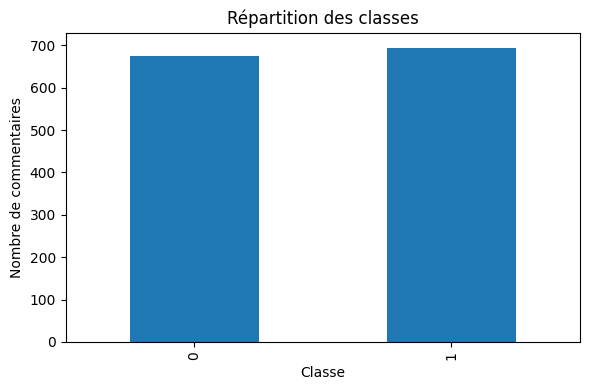

In [4]:
print("Informations sur les données :")
train.info()

print("\nValeurs manquantes :")
print(train.isna().sum())

print("\nRépartition de la variable CLASS :")
print(train["CLASS"].value_counts(dropna=False))

train["CLASS"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 4),
    title="Répartition des classes"
)
plt.xlabel("Classe")
plt.ylabel("Nombre de commentaires")
plt.tight_layout()
plt.show()

## 3. Nettoyage des commentaires

Le texte peut contenir des liens, des mentions, des caractères spéciaux ou plusieurs espaces.

On construit une fonction simple pour obtenir une version plus régulière du commentaire.

On conserve volontairement une fonction de nettoyage assez simple : l'objectif est de ne pas supprimer des informations utiles avant même d'avoir testé le modèle.

In [5]:
# Quelques mots vides en anglais.
# Les commentaires YouTube du jeu de données sont principalement en anglais.
mots_vides = {
    "a", "an", "the", "and", "or", "to", "of", "in", "on", "for",
    "is", "are", "was", "were", "this", "that", "it", "with", "as",
    "be", "at", "by", "from"
}

def nettoyer_texte(texte):
    if not isinstance(texte, str):
        return ""

    texte = texte.lower()
    texte = re.sub(r"https?://\S+|www\.\S+", " ", texte)
    texte = re.sub(r"@\w+", " ", texte)
    texte = re.sub(r"\s+", " ", texte).strip()

    tokens = [
        mot for mot in texte.split()
        if mot not in mots_vides and len(mot) > 1
    ]

    return " ".join(tokens)

train["CONTENT_CLEAN"] = train["CONTENT"].fillna("").apply(nettoyer_texte)
test["CONTENT_CLEAN"] = test["CONTENT"].fillna("").apply(nettoyer_texte)

print(train[["CONTENT", "CONTENT_CLEAN"]].head())

                                             CONTENT  \
0   HI IM 14 YEAR RAPPER SUPPORT ME GUY AND CHECK...   
1                                    Wow dance show﻿   
2  Lets be honest, you wouldn't last 1 day on you...   
3         Check out this playlist on YouTube:👿👳👳👳👳👳﻿   
4  do you guys know, there&#39;s a part two of th...   

                                       CONTENT_CLEAN  
0  hi im 14 year rapper support me guy check out ...  
1                                    wow dance show﻿  
2  lets honest, you wouldn't last day your own ju...  
3                 check out playlist youtube:👿👳👳👳👳👳﻿  
4   do you guys know, there&#39;s part two song! :d﻿  


## 4. Quelques variables supplémentaires

Le texte est l'information principale, mais on peut aussi utiliser quelques caractéristiques simples :

- longueur du commentaire ;
- proportion de lettres majuscules ;
- nombre de signes de ponctuation ;
- heure de publication ;
- jour de la semaine ;
- mois de publication ;
- fréquence de l'auteur ;
- fréquence de la vidéo.

Ces variables permettent de tester si le comportement du commentaire, du compte ou du contexte de publication apporte une information supplémentaire au texte.

In [6]:
# Mise au format date
for df in [train, test]:
    if "DATE" in df.columns:
        df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
    else:
        df["DATE"] = pd.NaT

def taux_majuscules(texte):
    texte = str(texte)
    lettres = [c for c in texte if c.isalpha()]
    if not lettres:
        return 0.0
    return sum(c.isupper() for c in lettres) / len(lettres)

def nombre_ponctuation(texte):
    return sum(c in string.punctuation for c in str(texte))

def ajouter_variables_simples(df, freq_auteur=None, freq_video=None):
    df = df.copy()

    df["CONTENT_LEN"] = df["CONTENT"].fillna("").astype(str).str.len()
    df["CAPS_RATIO"] = df["CONTENT"].fillna("").apply(taux_majuscules)
    df["PUNCT_COUNT"] = df["CONTENT"].fillna("").apply(nombre_ponctuation)

    df["DATE_HOUR"] = df["DATE"].dt.hour.fillna(-1).astype(int)
    df["DATE_DOW"] = df["DATE"].dt.dayofweek.fillna(-1).astype(int)
    df["DATE_MONTH"] = df["DATE"].dt.month.fillna(-1).astype(int)

    if "AUTHOR" in df.columns:
        df["AUTHOR"] = df["AUTHOR"].fillna("").astype(str)
        if freq_auteur is not None:
            df["AUTHOR_FREQ"] = df["AUTHOR"].map(freq_auteur).fillna(0)
        else:
            df["AUTHOR_FREQ"] = 0.0
    else:
        df["AUTHOR_FREQ"] = 0.0

    if "VIDEO" in df.columns:
        df["VIDEO"] = df["VIDEO"].fillna("").astype(str)
    elif "VIDEO_NAME" in df.columns:
        df["VIDEO"] = df["VIDEO_NAME"].fillna("").astype(str)
    else:
        df["VIDEO"] = ""

    if freq_video is not None:
        df["VIDEO_FREQ"] = df["VIDEO"].map(freq_video).fillna(0)
    else:
        df["VIDEO_FREQ"] = 0.0

    return df

# On garde les données brutes pour le moment.
train.head()

,Unnamed: 0,COMMENT_ID,AUTHOR,DATE,CONTENT,VIDEO_NAME,CLASS,CONTENT_CLEAN
0,1574,LneaDw26bFsFwQBcbaeKWWcSsBB7EA1zRf2nBgT9NyY,Ashim Limbu,NaT,HI IM 14 YEAR RAPPER SUPPORT ME GUY AND CHECK...,Eminem - Love The Way You Lie ft. Rihanna,1,hi im 14 year rapper support me guy check out ...
1,859,z13zvnepkwvgirzi104cdf1pyyyecthieew,Ali Altınışık,2015-05-18 10:56:12.254,Wow dance show﻿,"LMFAO - Party Rock Anthem ft. Lauren Bennett, ...",0,wow dance show﻿
2,651,z12kh3rhbs3duzfea23hzf1qhlyuextzx04,Bobby Carlos,NaT,"Lets be honest, you wouldn't last 1 day on you...",Katy Perry - Roar,0,"lets honest, you wouldn't last day your own ju..."
3,1018,z12cvbyjjmuwvxivx223tpujulrwwdt5j04,ampai gmuer,2015-01-27 13:23:56.061,Check out this playlist on YouTube:👿👳👳👳👳👳﻿,"LMFAO - Party Rock Anthem ft. Lauren Bennett, ...",1,check out playlist youtube:👿👳👳👳👳👳﻿
4,1288,z13xx5w52svttd3lt23kijvwqtvph5m3l,sparkle princess,2015-05-26 07:39:34.920,"do you guys know, there&#39;s a part two of th...",Eminem - Love The Way You Lie ft. Rihanna,0,"do you guys know, there&#39;s part two song! :d﻿"


## 5. Séparation des données

On sépare le fichier d'entraînement en deux parties :

- un jeu d'entraînement ;
- un jeu de validation.

In [7]:
train_interne, validation = train_test_split(
    train,
    test_size=0.20,
    stratify=train["CLASS"],
    random_state=42
)

train_interne = train_interne.copy()
validation = validation.copy()

print("Taille entraînement :", train_interne.shape)
print("Taille validation   :", validation.shape)

Taille entraînement : (1095, 8)
Taille validation   : (274, 8)


## 6. Encoder les informations sur l'auteur et la vidéo

On utilise ici une **fréquence d'apparition**.

Par exemple, si un auteur apparaît souvent dans le jeu d'entraînement, son encodage sera plus élevé.

In [10]:
# Fréquences calculées uniquement sur train_interne
freq_auteur = train_interne["AUTHOR"].fillna("").astype(str).value_counts(normalize=True)
freq_video = train_interne["VIDEO_NAME"].fillna("").astype(str).value_counts(normalize=True)

train_interne = ajouter_variables_simples(
    train_interne,
    freq_auteur=freq_auteur,
    freq_video=freq_video
)

validation = ajouter_variables_simples(
    validation,
    freq_auteur=freq_auteur,
    freq_video=freq_video
)

NUM_FEATURES = [
    "AUTHOR_FREQ",
    "VIDEO_FREQ",
    "DATE_HOUR",
    "DATE_DOW",
    "DATE_MONTH",
    "CONTENT_LEN",
    "CAPS_RATIO",
    "PUNCT_COUNT"
]

train_interne[NUM_FEATURES].head()

,AUTHOR_FREQ,VIDEO_FREQ,DATE_HOUR,DATE_DOW,DATE_MONTH,CONTENT_LEN,CAPS_RATIO,PUNCT_COUNT
1225,0.000913,0.234703,-1,-1,-1,35,0.000000,0
594,0.000913,0.197260,9,3,10,37,0.064516,2
581,0.000913,0.187215,-1,-1,-1,50,0.025641,8
897,0.000913,0.187215,-1,-1,-1,57,0.043478,0
677,0.001826,0.234703,-1,-1,-1,373,0.140351,13


## 7. Représenter les commentaires avec TF-IDF

On utilise donc **TF-IDF**.

L'idée est de donner plus de poids aux mots qui sont fréquents dans un commentaire mais moins fréquents dans l'ensemble des commentaires.

On teste aussi les **bigrammes** : des groupes de deux mots consécutifs. Cela peut permettre de conserver des expressions utiles comme `subscribe now` ou `check channel`.

In [11]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    stop_words="english"
)

X_train_text = tfidf.fit_transform(train_interne["CONTENT_CLEAN"])
X_val_text = tfidf.transform(validation["CONTENT_CLEAN"])

print("Nombre de caractéristiques TF-IDF :", X_train_text.shape[1])

Nombre de caractéristiques TF-IDF : 840


## 8. Préparer les variables numériques

Les variables numériques n'ont pas toutes la même échelle. Par exemple, une longueur de commentaire peut être beaucoup plus grande qu'un ratio compris entre 0 et 1.

On les standardise avant de les ajouter aux variables textuelles.

In [12]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(train_interne[NUM_FEATURES])
X_val_num = scaler.transform(validation[NUM_FEATURES])

# Conversion en matrice creuse pour pouvoir la concaténer avec TF-IDF.
X_train_num = csr_matrix(X_train_num)
X_val_num = csr_matrix(X_val_num)

## 9. Construire les variables finales

On rassemble :

1. les variables TF-IDF issues du texte ;
2. les variables numériques décrivant le commentaire ;
3. les variables simples liées à l'auteur, à la vidéo et à la date.

Le modèle recevra donc une seule matrice contenant l'ensemble de ces informations.

In [13]:
X_train_final = hstack([X_train_text, X_train_num])
X_val_final = hstack([X_val_text, X_val_num])

y_train = train_interne["CLASS"].astype(int)
y_val = validation["CLASS"].astype(int)

print("Taille finale train :", X_train_final.shape)
print("Taille finale val   :", X_val_final.shape)

Taille finale train : (1095, 848)
Taille finale val   : (274, 848)


## 10. Premier modèle : régression logistique

Pour une première approche, on utilise une **régression logistique**.

Même si son nom contient le mot « régression », elle est couramment utilisée pour résoudre des problèmes de classification binaire.

Elle est intéressante ici comme premier modèle car elle est :

- relativement simple ;
- rapide à entraîner sur des données TF-IDF ;
- facile à interpréter ;
- directement disponible dans scikit-learn.

In [14]:
modele = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

modele.fit(X_train_final, y_train)

y_val_pred = modele.predict(X_val_final)
y_val_proba = modele.predict_proba(X_val_final)[:, 1]

print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("ROC-AUC  :", roc_auc_score(y_val, y_val_proba))

print("\nRapport de classification :")
print(classification_report(y_val, y_val_pred, digits=4))

Accuracy : 0.8211678832116789
ROC-AUC  : 0.9650945909938715

Rapport de classification :
              precision    recall  f1-score   support

           0     0.7443    0.9704    0.8424       135
           1     0.9592    0.6763    0.7932       139

    accuracy                         0.8212       274
   macro avg     0.8518    0.8233    0.8178       274
weighted avg     0.8533    0.8212    0.8175       274



## 11. Matrice de confusion

La matrice de confusion permet de voir plus précisément les erreurs du modèle :

- vrais négatifs ;
- faux positifs ;
- faux négatifs ;
- vrais positifs.

Elle permet de compléter l'accuracy, qui ne donne pas le détail des erreurs.

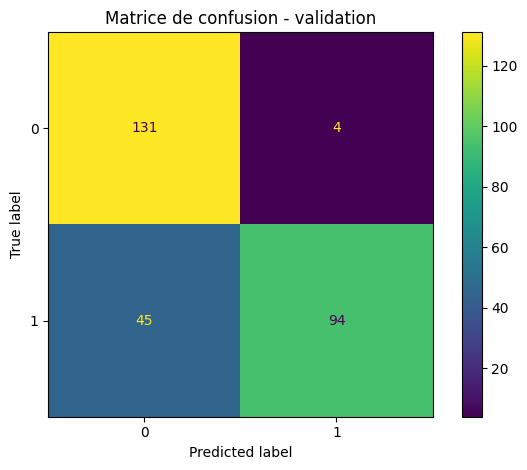

In [15]:
matrice = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=matrice)
disp.plot()
plt.title("Matrice de confusion - validation")
plt.tight_layout()
plt.show()

## 12. Tester quelques valeurs de `C`

Le paramètre `C` contrôle le compromis entre la régularisation et l'ajustement aux données.

Plutôt que de choisir arbitrairement une valeur, on teste quelques possibilités avec une validation croisée sur le jeu d'entraînement interne.

Le jeu de validation final n'est pas utilisé pour ce choix.

In [16]:
parametres = {
    "C": [0.1, 0.5, 1, 2, 5]
}

recherche = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    param_grid=parametres,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

recherche.fit(X_train_final, y_train)

print("Meilleur C :", recherche.best_params_["C"])
print("Meilleure accuracy moyenne en validation croisée :", recherche.best_score_)

Meilleur C : 5
Meilleure accuracy moyenne en validation croisée : 0.9159817351598174


## 13. Évaluation du meilleur modèle

On évalue maintenant le meilleur modèle choisi par validation croisée sur le jeu de validation qui n'a pas servi à sélectionner `C`.

Accuracy : 0.8722627737226277
ROC-AUC  : 0.9731947775113243

Rapport de classification :
              precision    recall  f1-score   support

           0     0.8086    0.9704    0.8822       135
           1     0.9643    0.7770    0.8606       139

    accuracy                         0.8723       274
   macro avg     0.8865    0.8737    0.8714       274
weighted avg     0.8876    0.8723    0.8712       274



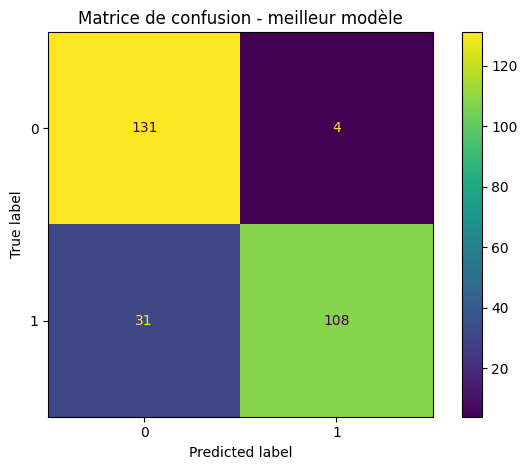

In [17]:
meilleur_modele = recherche.best_estimator_

y_val_pred = meilleur_modele.predict(X_val_final)
y_val_proba = meilleur_modele.predict_proba(X_val_final)[:, 1]

print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("ROC-AUC  :", roc_auc_score(y_val, y_val_proba))

print("\nRapport de classification :")
print(classification_report(y_val, y_val_pred, digits=4))

ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred)
plt.title("Matrice de confusion - meilleur modèle")
plt.tight_layout()
plt.show()

## 14. Entraînement final sur toutes les données étiquetées

Après avoir choisi les paramètres, on peut réutiliser toutes les données de `train_yt.csv` pour entraîner le modèle final.

Cette fois, les fréquences de l'auteur et de la vidéo sont calculées sur l'ensemble du train, car il n'y a plus de jeu de validation à préserver.

In [20]:
train_final = train.copy()
test_final = test.copy()

freq_auteur_final = train_final["AUTHOR"].fillna("").astype(str).value_counts(normalize=True)
freq_video_final = train_final["VIDEO_NAME"].fillna("").astype(str).value_counts(normalize=True)

train_final = ajouter_variables_simples(
    train_final,
    freq_auteur=freq_auteur_final,
    freq_video=freq_video_final
)

test_final = ajouter_variables_simples(
    test_final,
    freq_auteur=freq_auteur_final,
    freq_video=freq_video_final
)

# Nouvelle vectorisation : elle est maintenant apprise sur tout le train.
tfidf_final = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    stop_words="english"
)

X_train_text_final = tfidf_final.fit_transform(train_final["CONTENT_CLEAN"])
X_test_text_final = tfidf_final.transform(test_final["CONTENT_CLEAN"])

scaler_final = StandardScaler()
X_train_num_final = csr_matrix(
    scaler_final.fit_transform(train_final[NUM_FEATURES])
)
X_test_num_final = csr_matrix(
    scaler_final.transform(test_final[NUM_FEATURES])
)

X_train_final_complet = hstack([
    X_train_text_final,
    X_train_num_final
])

X_test_final_complet = hstack([
    X_test_text_final,
    X_test_num_final
])

y_final = train_final["CLASS"].astype(int)

modele_final = LogisticRegression(
    C=recherche.best_params_["C"],
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

modele_final.fit(X_train_final_complet, y_final)

print("Entraînement final terminé.")
print("Taille des données d'entraînement :", X_train_final_complet.shape)
print("Taille des données de test        :", X_test_final_complet.shape)

Entraînement final terminé.
Taille des données d'entraînement : (1369, 1042)
Taille des données de test        : (587, 1042)


## 15. Prédictions sur `test_yt.csv`

In [21]:
y_pred_test = modele_final.predict(X_test_final_complet)

# On conserve l'identifiant d'origine quand il existe.
if "Unnamed: 0" in test.columns:
    identifiants = test["Unnamed: 0"]
elif "ID" in test.columns:
    identifiants = test["ID"]
else:
    identifiants = np.arange(len(test))

predictions = pd.DataFrame({
    "ID": identifiants,
    "y_pred": y_pred_test
})

predictions.to_csv("predictions.csv", index=False)

print("Fichier predictions.csv créé.")
print(predictions.head())

Fichier predictions.csv créé.
     ID  y_pred
0  1360       0
1  1703       0
2  1146       0
3  1758       1
4   374       0
